In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [75]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x000001ad1328eab0>

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [29]:
Main.include("..\\strong coupling\\constants.jl")
Main.include("..\\strong coupling\\alpha_s.jl")
Main.include("..\\anomalous dim\\cusp\\cusp.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaH.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaB.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaS.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammav.jl")
Main.include("..\\hard\\hard.jl")
Main.include("..\\jet\\jet.jl")
Main.include("..\\soft\\soft.jl")
Main.include("..\\sigma.jl")
Main.include("..\\error.jl")
Main.include("..\\fixed order\\perturbation.jl")
Main.include("..\\fixed order\\SCET.jl")
Main.include("..\\fixed order\\non-singular.jl")
Main.include("..\\renormalon.jl")

Main.include("data\\OPAL.jl")

array([3.24 , 1.3  , 1.38 , 1.197, 0.974, 0.796, 0.661, 0.553, 0.461,
       0.39 , 0.334, 0.289, 0.255, 0.227, 0.206, 0.188, 0.174, 0.161,
       0.15 , 0.141, 0.133, 0.127, 0.121, 0.116, 0.11 , 0.106, 0.102,
       0.099, 0.096, 0.093, 0.091, 0.089, 0.087, 0.085, 0.083, 0.081,
       0.081, 0.079, 0.078, 0.077, 0.076, 0.076, 0.075, 0.075, 0.075,
       0.075, 0.074, 0.074, 0.074, 0.075, 0.076, 0.076, 0.076, 0.078,
       0.078, 0.079, 0.08 , 0.082, 0.083, 0.085, 0.087, 0.089, 0.091,
       0.094, 0.096, 0.099, 0.102, 0.107, 0.11 , 0.116, 0.121, 0.125,
       0.131, 0.138, 0.146, 0.155, 0.164, 0.174, 0.186, 0.2  , 0.213,
       0.23 , 0.25 , 0.272, 0.299, 0.329, 0.365, 0.41 , 0.457, 0.521,
       0.595, 0.682, 0.783, 0.906, 1.049, 1.19 , 1.31 , 1.34 , 1.12 ,
       0.46 ])

In [30]:
χ_OPAL = np.array([
    0.9,   2.7,   4.5,   6.3,   8.1,   9.9, 
    11.7,  13.5,  15.3,  17.1,  18.9,
    20.7,  22.5,  24.3,  26.1,  27.9,  29.7, 
    31.5,  33.3,  35.1,  36.9,  38.7,
    40.5,  42.3,  44.1,  45.9,  47.7,  49.5, 
    51.3,  53.1,  54.9,  56.7,  58.5, 
    60.3,  62.1,  63.9,  65.7,  67.5,  69.3, 
    71.1,  72.9,  74.7,  76.5,  78.3,  
    80.1,  81.9,  83.7,  85.5,  87.3,  89.1, 
    90.9,  92.7,  94.5,  96.3,  98.1,  99.9, 
    101.7, 103.5, 105.3, 107.1, 108.9, 
    110.7, 112.5, 114.3, 116.1, 117.9, 119.7, 
    121.5, 123.3, 125.1, 126.9, 128.7, 
    130.5, 132.3, 134.1, 135.9, 137.7, 139.5, 
    141.3, 143.1, 144.9, 146.7, 148.5,
    150.3, 152.1, 153.9, 155.7, 157.5, 159.3,
    161.1, 162.9, 164.7, 166.5, 168.3,
    170.1, 171.9, 173.7, 175.5, 177.3, 179.1
])

EEC_OPAL = np.array([
    3.24,  1.30,  1.38,  1.197, 0.974, 0.796, 
    0.661, 0.553, 0.461, 0.390, 0.334, 
    0.289, 0.255, 0.227, 0.206, 0.188, 0.174, 
    0.161, 0.150, 0.141, 0.133, 0.127, 
    0.121, 0.116, 0.110, 0.106, 0.102, 0.099, 
    0.096, 0.093, 0.091, 0.089, 0.087, 
    0.085, 0.083, 0.081, 0.081, 0.079, 0.078, 
    0.077, 0.076, 0.076, 0.075, 0.075, 
    0.075, 0.075, 0.074, 0.074, 0.074, 0.075, 
    0.076, 0.076, 0.076, 0.078, 0.078, 0.079, 
    0.080, 0.082, 0.083, 0.085, 0.087, 
    0.089, 0.091, 0.094, 0.096, 0.099, 0.102, 
    0.107, 0.110, 0.116, 0.121, 0.125, 
    0.131, 0.138, 0.146, 0.155, 0.164, 0.174, 
    0.186, 0.200, 0.213, 0.230, 0.250, 
    0.272, 0.299, 0.329, 0.365, 0.410, 0.457, 
    0.521, 0.595, 0.682, 0.783, 0.906, 
    1.049, 1.19,  1.31,  1.34,  1.12,  0.46
])

In [5]:
print(EEC_OPAL)

[3.24  1.3   1.38  1.197 0.974 0.796 0.661 0.553 0.461 0.39  0.334 0.289
 0.255 0.227 0.206 0.188 0.174 0.161 0.15  0.141 0.133 0.127 0.121 0.116
 0.11  0.106 0.102 0.099 0.096 0.093 0.091 0.089 0.087 0.085 0.083 0.081
 0.081 0.079 0.078 0.077 0.076 0.076 0.075 0.075 0.075 0.075 0.074 0.074
 0.074 0.075 0.076 0.076 0.076 0.078 0.078 0.079 0.08  0.082 0.083 0.085
 0.087 0.089 0.091 0.094 0.096 0.099 0.102 0.107 0.11  0.116 0.121 0.125
 0.131 0.138 0.146 0.155 0.164 0.174 0.186 0.2   0.213 0.23  0.25  0.272
 0.299 0.329 0.365 0.41  0.457 0.521 0.595 0.682 0.783 0.906 1.049 1.19
 1.31  1.34  1.12  0.46 ]


In [45]:
xlist = np.pi/180*np.linspace(10,179.9,100)
length=len(xlist)

#v_1 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=1)
v_2 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2, Ω1=0.0)
#v_3 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=3)

In [37]:
#xlist = np.pi/180*np.linspace(120,180,200)
perturbation_2 = []
non_singular_2 = []
non_singular_3 = []

for x in xlist:
    non_singular_2.append(Main.non_singular_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2)) 
    perturbation_2.append(Main.perturbation_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2))
    non_singular_3.append(Main.non_singular_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=0.118, nf=5, order=3))     
print(perturbation_2)

[447.214271160093, 107.57551735237845, 31.558079667195678, 10.816783427025097, 4.227819438991759, 1.8642234284829788, 0.9264061219955665, 0.5204344369540543, 0.33030246011062075, 0.23437391038534064, 0.18230099630198102, 0.15188581037527493, 0.13277906490965238, 0.11990600262711623, 0.11065977591262939, 0.10364129510890131, 0.09806733268618792, 0.09348093965391353, 0.08960438790297029, 0.0862618726534805, 0.08333755140460786, 0.08075205883798955, 0.07844897178970202, 0.07638678390742733, 0.07453401297721797, 0.0728661352332216, 0.0713636117503383, 0.070010583565424, 0.06879398615276563, 0.06770293315756809, 0.06672827713443633, 0.06586228941368984, 0.06509842205060253, 0.06443112767394056, 0.06385572114330582, 0.06336827210896778, 0.06296552095274464, 0.06264481283913106, 0.062404046131621246, 0.062241632484194294, 0.062156466663286156, 0.06214790469431507, 0.062215749326568176, 0.06236024211587698, 0.06258206166615561, 0.06288232777006265, 0.06326261136036677, 0.06372495033885212, 0.0

In [38]:
df_OPAL = pd.read_csv("data/OPAL.csv")
truncated_OPAL = df_OPAL

χ_OPAL = np.array(truncated_OPAL["CHI"])
EEC_OPAL = np.array(truncated_OPAL["EEC"])
STAT_OPAL = np.array(truncated_OPAL["STAT"])

In [72]:
non_singular = []
perturbation = []

χ_OPAL_trans = np.pi/180*χ_OPAL
resum = Main.sigma_fast(Q=91.2, χ_list=χ_OPAL_trans, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2, Ω1=0.0)
for x in χ_OPAL_trans:
    non_singular.append(Main.non_singular_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2)) 
    perturbation.append(Main.perturbation_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2)) 
residual = resum + non_singular - EEC_OPAL

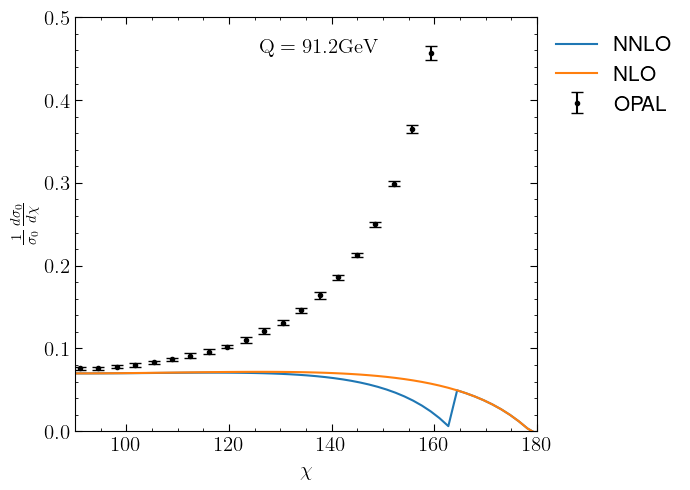

In [77]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

#ax1.plot(xlist*180/np.pi, perturbation_1, label="LO")
#ax1.plot(xlist*180/np.pi, perturbation_2, label="NLO")
#ax1.plot(xlist*180/np.pi, v_2+non_singular_2, label="matched total")
ax1.errorbar(χ_OPAL[::2], EEC_OPAL[::2], yerr=STAT_OPAL[::2], fmt='o',label="OPAL",color="black", capsize=4,markersize=3)
ax1.plot(xlist*180/np.pi, non_singular_3, label="NNLO")
ax1.plot(xlist*180/np.pi, non_singular_2, label="NLO")
#ax1.plot(χ_OPAL, -residual, label="error_resum")
#ax1.plot(χ_OPAL, -(perturbation-EEC_OPAL), label="error_perturbation")


ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

plt.ylim(0,0.5)
plt.xlim(90,180)

#plt.xticks([0,30,60,90,120,150,180])
#plt.yticks([0.3,0.6,0.9,1.2,1.5,1.8])

plt.tight_layout()  
plt.show()

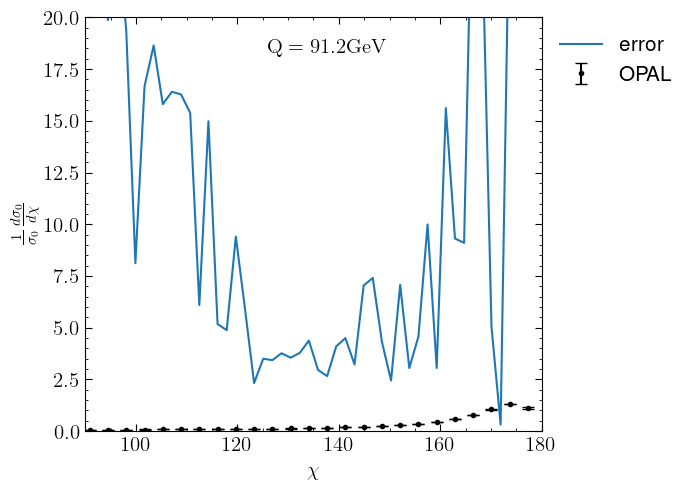

In [63]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

#ax1.plot(xlist*180/np.pi, perturbation_1, label="LO")
#ax1.plot(xlist*180/np.pi, perturbation_2, label="NLO")
#ax1.plot(xlist*180/np.pi, v_2+non_singular_2, label="matched total")
ax1.errorbar(χ_OPAL[::2], EEC_OPAL[::2], yerr=STAT_OPAL[::2], fmt='o',label="OPAL",color="black", capsize=4,markersize=3)
#ax1.plot(xlist*180/np.pi, non_singular_3, label="NNLO")
#ax1.plot(xlist*180/np.pi, non_singular_2, label="NLO")
ax1.plot(χ_OPAL, (residual/STAT_OPAL)**2, label="error")

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

plt.ylim(0,20)
plt.xlim(90,180)

#plt.xticks([0,30,60,90,120,150,180])
#plt.yticks([0.3,0.6,0.9,1.2,1.5,1.8])

plt.tight_layout()  
plt.show()